# T-Learner Robustness and Sensitivity Analysis

This notebook evaluates whether the main T-learner uplift conclusions are robust to randomized treatment labels, test-set resampling, and alternative train/test splits.

The checks focus on the **Logistic T-learner**, which is the best-performing T-learner in the current saved evaluation results. The notebook reports:

- a placebo-treatment test,
- bootstrap confidence intervals for the visit ATE, top-decile lift, Qini, and AUUC,
- repeated-split stability for Qini, AUUC, and top-decile lift,
- a consolidated robustness summary and short interpretation.

**Repository note:** in the supplied snapshot, `10_evaluation_qini_auuc.ipynb` is still a TODO and does not yet save a unified prediction file. Until that notebook is implemented, this notebook loads the shared processed data plus the current T-learner prediction/evaluation outputs. The loading section is isolated so it can be switched to a future unified prediction file later.

## 1. Import required libraries

This section imports the modeling, resampling, plotting, and CausalML evaluation tools used in the robustness checks.

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from causalml.metrics import plot_qini

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.style.use("seaborn-v0_8-darkgrid")

/Users/chris/.venvs/comp653/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configure project paths and robustness settings

This section locates the repository root, imports the shared project configuration and metric helpers, and defines the number of bootstrap repetitions and repeated train/test splits.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    PROCESSED_DATA_DIR,
    PREDICTIONS_DIR,
    MODEL_RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    OUTPUTS_DIR,
    RANDOM_STATE,
    TEST_SIZE,
)

from src.metrics import (
    build_uplift_eval_frame,
    compute_qini_auuc,
    uplift_at_top_k,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

N_BOOTSTRAPS = 300
N_STABILITY_SPLITS = 10
TOP_FRACTION = 0.10

ROBUSTNESS_SUMMARY_PATH = OUTPUTS_DIR / "robustness_summary.csv"
PLACEBO_QINI_PATH = FIGURES_DIR / "robustness_placebo_qini.png"
BOOTSTRAP_CI_PATH = FIGURES_DIR / "bootstrap_confidence_intervals.png"

print("Project root:", PROJECT_ROOT)
print("Robustness summary:", ROBUSTNESS_SUMMARY_PATH)
print("Figure directory:", FIGURES_DIR)

Project root: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling
Robustness summary: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/robustness_summary.csv
Figure directory: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/figures


## 3. Load the shared modeling data and saved T-learner outputs

This section loads the same processed train/test data used by the T-learner notebook together with the saved T-learner predictions, uplift metrics, decile results, and model metadata.

 `t_learner_predictions.csv` is used as the current source of model scores.

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")

y_train = pd.read_csv(
    PROCESSED_DATA_DIR / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    PROCESSED_DATA_DIR / "y_test.csv"
).squeeze("columns")

treatment_train = pd.read_csv(
    PROCESSED_DATA_DIR / "treatment_train.csv"
).squeeze("columns")

treatment_test = pd.read_csv(
    PROCESSED_DATA_DIR / "treatment_test.csv"
).squeeze("columns")

t_learner_predictions = pd.read_csv(
    PREDICTIONS_DIR / "t_learner_predictions.csv"
)

t_learner_performance = pd.read_csv(
    TABLES_DIR / "t_learner_uplift_performance.csv"
)

t_learner_deciles = pd.read_csv(
    TABLES_DIR / "t_learner_decile_results.csv"
)

with open(
    MODEL_RESULTS_DIR / "t_learner_results.json",
    "r",
) as file:
    t_learner_results = json.load(file)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
display(t_learner_performance)

Training observations: 48000
Testing observations: 16000


,Model,Qini score,AUUC
0,Logistic T-learner,0.0890,0.5920
1,XGBoost T-learner,0.0443,0.5458
2,Random Forest T-learner,0.0444,0.5460


## 4. Validate the loaded predictions and select the main uplift model

This section confirms that the saved prediction rows match the shared test outcome and treatment files. It then identifies the current best T-learner from the saved Qini results.

The current project results select the Logistic T-learner, so the re-fitting sensitivity checks below use that model.

In [4]:
assert len(t_learner_predictions) == len(y_test) == len(treatment_test)

assert np.array_equal(
    t_learner_predictions["y_true"].to_numpy(),
    y_test.to_numpy(),
)

assert np.array_equal(
    t_learner_predictions["treatment"].to_numpy(),
    treatment_test.to_numpy(),
)

best_model_row = (
    t_learner_performance
    .sort_values(
        ["Qini score", "AUUC"],
        ascending=False,
    )
    .iloc[0]
)

BEST_MODEL_NAME = best_model_row["Model"]

prediction_column_map = {
    "Logistic T-learner": "lgr_predicted_uplift",
    "XGBoost T-learner": "xgb_predicted_uplift",
    "Random Forest T-learner": "rf_predicted_uplift",
}

BEST_PREDICTION_COLUMN = prediction_column_map[BEST_MODEL_NAME]
best_model_uplift = t_learner_predictions[
    BEST_PREDICTION_COLUMN
].to_numpy()

print("Best saved T-learner:", BEST_MODEL_NAME)
print("Prediction column:", BEST_PREDICTION_COLUMN)

assert BEST_MODEL_NAME == "Logistic T-learner", (
    "The current robustness re-fitting code is configured for the "
    "Logistic T-learner because it is the best model in the supplied results."
)

Best saved T-learner: Logistic T-learner
Prediction column: lgr_predicted_uplift


## 5. Recover the Logistic T-learner hyperparameters

The original T-learner selected its logistic regularization parameters by cross-validation. For the sensitivity reruns, those selected parameters are held fixed so changes in the results reflect treatment randomization or sampling variation rather than repeated hyperparameter tuning.

In [5]:
logistic_results = t_learner_results["lgr_t_learner"]

LOGISTIC_BASE_PARAMETERS = (
    logistic_results["base_parameters"].copy()
)

TREATED_C = (
    logistic_results["cross_validation"]
    ["treated_model"]
    ["best_parameters"]
    ["C"]
)

CONTROL_C = (
    logistic_results["cross_validation"]
    ["control_model"]
    ["best_parameters"]
    ["C"]
)

print("Logistic base parameters:", LOGISTIC_BASE_PARAMETERS)
print("Treated-model C:", TREATED_C)
print("Control-model C:", CONTROL_C)

Logistic base parameters: {'max_iter': 2000, 'solver': 'lbfgs'}
Treated-model C: 1.0
Control-model C: 1.0


## 6. Define reusable modeling and evaluation helpers

These functions re-fit the Logistic T-learner, calculate customer-level uplift, compute the visit ATE, evaluate Qini/AUUC through CausalML, and measure observed lift within the top 10% of ranked customers.

In [6]:
def fit_logistic_t_learner(
    X,
    y,
    treatment,
    treated_c=TREATED_C,
    control_c=CONTROL_C,
):
    treatment_array = np.asarray(treatment)
    y_array = np.asarray(y)

    treated_mask = treatment_array == 1
    control_mask = treatment_array == 0

    treated_model = LogisticRegression(
        **LOGISTIC_BASE_PARAMETERS,
        C=treated_c,
    )

    control_model = LogisticRegression(
        **LOGISTIC_BASE_PARAMETERS,
        C=control_c,
    )

    treated_model.fit(
        X.iloc[treated_mask],
        y_array[treated_mask],
    )

    control_model.fit(
        X.iloc[control_mask],
        y_array[control_mask],
    )

    return treated_model, control_model


def predict_t_learner_uplift(
    treated_model,
    control_model,
    X,
):
    pred_if_treated = (
        treated_model.predict_proba(X)[:, 1]
    )

    pred_if_control = (
        control_model.predict_proba(X)[:, 1]
    )

    return pred_if_treated - pred_if_control


def calculate_ate(y, treatment):
    y_array = np.asarray(y)
    treatment_array = np.asarray(treatment)

    return float(
        y_array[treatment_array == 1].mean()
        - y_array[treatment_array == 0].mean()
    )


def evaluate_uplift(
    y,
    treatment,
    predicted_uplift,
    model_name,
):
    scores = compute_qini_auuc(
        y=y,
        treatment=treatment,
        tau_hat_dict={
            model_name: np.asarray(predicted_uplift)
        },
        normalize=True,
    )

    top_result = uplift_at_top_k(
        y=y,
        treatment=treatment,
        tau_hat=predicted_uplift,
        k=TOP_FRACTION,
    )

    return {
        "ate": calculate_ate(y, treatment),
        "top_decile_lift": float(
            top_result["actual_lift"]
        ),
        "qini": float(
            scores["qini_score"].loc[model_name]
        ),
        "auuc": float(
            scores["auuc_score"].loc[model_name]
        ),
    }


def random_targeting_reference(
    y,
    treatment,
    n_draws=25,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)
    rows = []

    for draw in range(n_draws):
        random_score = rng.normal(size=len(y))

        draw_metrics = evaluate_uplift(
            y=y,
            treatment=treatment,
            predicted_uplift=random_score,
            model_name="Random ranking",
        )

        rows.append(draw_metrics)

    return (
        pd.DataFrame(rows)
        .mean()
        .to_dict()
    )

## 7. Establish the original-model benchmark

Before perturbing the data, this section recomputes the main Logistic T-learner's ATE, top-decile lift, normalized Qini, and normalized AUUC from the saved test predictions. It also estimates a random-targeting reference using repeated random rankings.

In [7]:
baseline_metrics = evaluate_uplift(
    y=y_test,
    treatment=treatment_test,
    predicted_uplift=best_model_uplift,
    model_name=BEST_MODEL_NAME,
)

baseline_random_reference = random_targeting_reference(
    y=y_test,
    treatment=treatment_test,
    n_draws=25,
    seed=RANDOM_STATE + 1,
)

baseline_table = pd.DataFrame({
    "Metric": [
        "ATE",
        "Top-decile lift",
        "Qini",
        "AUUC",
    ],
    "Original model": [
        baseline_metrics["ate"],
        baseline_metrics["top_decile_lift"],
        baseline_metrics["qini"],
        baseline_metrics["auuc"],
    ],
    "Random-targeting reference": [
        baseline_metrics["ate"],
        baseline_random_reference["top_decile_lift"],
        baseline_random_reference["qini"],
        baseline_random_reference["auuc"],
    ],
})

display(baseline_table)

,Metric,Original model,Random-targeting reference
0,ATE,0.0611,0.0611
1,Top-decile lift,0.1184,0.0614
2,Qini,0.0890,-0.0036
3,AUUC,0.5920,0.4964


# Placebo Treatment Test

The placebo test breaks the treatment signal used for model fitting by randomly shuffling the **training treatment labels** while preserving the original treatment counts.

The held-out test treatment labels are intentionally left unchanged. This lets the re-fit placebo model be evaluated against the real randomized experiment. If the original uplift ranking is meaningful, the placebo model should look more like random targeting on the unchanged test set.

## 8. Shuffle the training treatment labels and re-fit the Logistic T-learner

This section creates a placebo training assignment and re-runs the same two-model Logistic T-learner using the fixed hyperparameters selected in the original notebook. The original test treatment labels remain untouched for evaluation.

In [8]:
placebo_rng = np.random.default_rng(
    RANDOM_STATE + 100
)

placebo_treatment_train = placebo_rng.permutation(
    treatment_train.to_numpy()
)

placebo_treated_model, placebo_control_model = (
    fit_logistic_t_learner(
        X=X_train,
        y=y_train,
        treatment=placebo_treatment_train,
    )
)

placebo_predicted_uplift = (
    predict_t_learner_uplift(
        treated_model=placebo_treated_model,
        control_model=placebo_control_model,
        X=X_test,
    )
)

print(
    "Original training treatment rate:",
    treatment_train.mean(),
)

print(
    "Placebo training treatment rate:",
    placebo_treatment_train.mean(),
)

print(
    "Test treatment labels remain unchanged:",
    True,
)

Original training treatment rate: 0.6670833333333334
Placebo training treatment rate: 0.6670833333333334
Test treatment labels remain unchanged: True


## 9. Evaluate the placebo model against random targeting

This section evaluates the placebo predictions using the **original held-out test outcomes and treatment assignments**. Qini, AUUC, and top-decile lift are compared with the original model and a random-ranking reference. The key diagnostic is whether the placebo model's distance from random targeting is smaller than the original model's distance from random.

In [9]:
placebo_metrics = evaluate_uplift(
    y=y_test,
    treatment=treatment_test,
    predicted_uplift=placebo_predicted_uplift,
    model_name="Placebo Logistic T-learner",
)

# The evaluation sample is unchanged, so the same random-targeting
# benchmark can be used for the original and placebo rankings.
placebo_random_reference = (
    baseline_random_reference.copy()
)

placebo_comparison = pd.DataFrame({
    "metric": [
        "qini",
        "auuc",
        "top_decile_lift",
    ],
    "original_model": [
        baseline_metrics["qini"],
        baseline_metrics["auuc"],
        baseline_metrics["top_decile_lift"],
    ],
    "original_random_reference": [
        baseline_random_reference["qini"],
        baseline_random_reference["auuc"],
        baseline_random_reference["top_decile_lift"],
    ],
    "placebo_model": [
        placebo_metrics["qini"],
        placebo_metrics["auuc"],
        placebo_metrics["top_decile_lift"],
    ],
    "placebo_random_reference": [
        placebo_random_reference["qini"],
        placebo_random_reference["auuc"],
        placebo_random_reference["top_decile_lift"],
    ],
})

placebo_comparison[
    "original_distance_from_random"
] = (
    placebo_comparison["original_model"]
    - placebo_comparison[
        "original_random_reference"
    ]
).abs()

placebo_comparison[
    "placebo_distance_from_random"
] = (
    placebo_comparison["placebo_model"]
    - placebo_comparison[
        "placebo_random_reference"
    ]
).abs()

placebo_comparison["closer_to_random"] = (
    placebo_comparison[
        "placebo_distance_from_random"
    ]
    < placebo_comparison[
        "original_distance_from_random"
    ]
)

print(
    "Original test-set ATE:",
    baseline_metrics["ate"],
)

print(
    "Placebo evaluation ATE:",
    placebo_metrics["ate"],
)

display(placebo_comparison)

Original test-set ATE: 0.06105172999608584
Placebo evaluation ATE: 0.06105172999608584


,metric,original_model,original_random_reference,placebo_model,placebo_random_reference,original_distance_from_random,placebo_distance_from_random,closer_to_random
0,qini,0.0890,-0.0036,0.0858,-0.0036,0.0926,0.0894,True
1,auuc,0.5920,0.4964,0.5889,0.4964,0.0956,0.0925,True
2,top_decile_lift,0.1184,0.0614,0.1116,0.0614,0.0570,0.0502,True


## 10. Plot the original and placebo Qini curves

Both panels use the same held-out test outcomes and treatment labels. Only the model ranking changes. The placebo curve should show less separation from random targeting than the original Logistic T-learner.

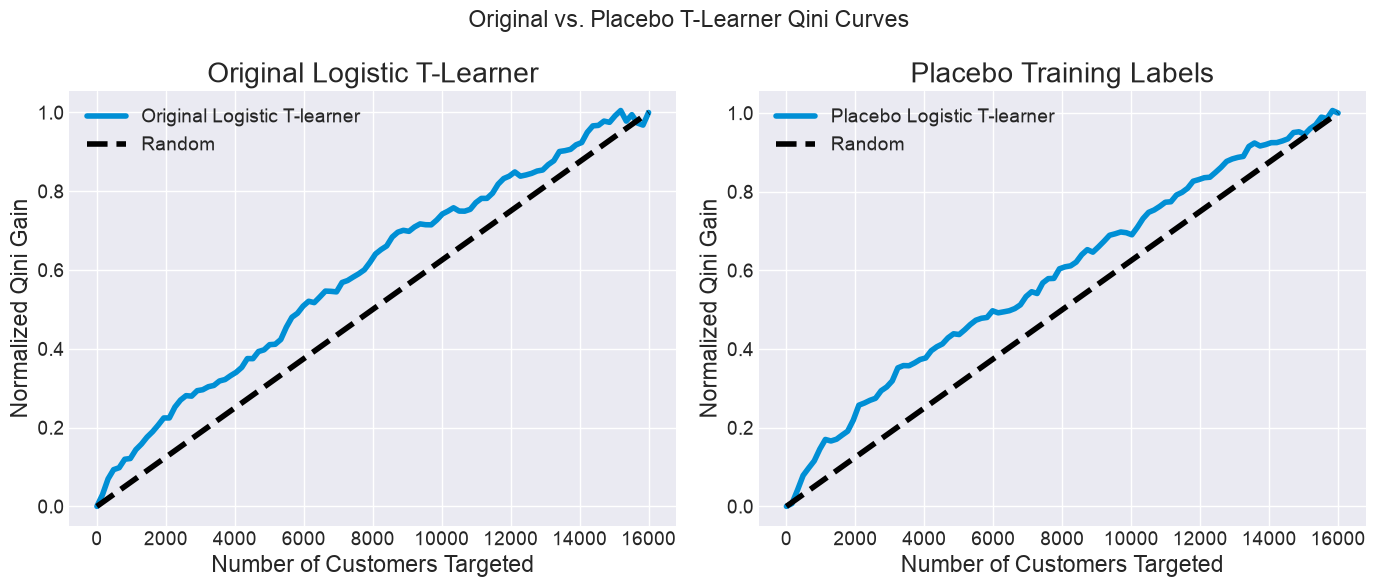

Saved: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/figures/robustness_placebo_qini.png


In [10]:
original_qini_df = build_uplift_eval_frame(
    y=y_test,
    treatment=treatment_test,
    tau_hat_dict={
        "Original Logistic T-learner":
            best_model_uplift
    },
)

placebo_qini_df = build_uplift_eval_frame(
    y=y_test,
    treatment=treatment_test,
    tau_hat_dict={
        "Placebo Logistic T-learner":
            placebo_predicted_uplift
    },
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

plot_qini(
    original_qini_df,
    outcome_col="y",
    treatment_col="w",
    normalize=True,
    n=100,
    ax=axes[0],
)

axes[0].set_title(
    "Original Logistic T-Learner"
)
axes[0].set_xlabel(
    "Number of Customers Targeted"
)
axes[0].set_ylabel(
    "Normalized Qini Gain"
)

plot_qini(
    placebo_qini_df,
    outcome_col="y",
    treatment_col="w",
    normalize=True,
    n=100,
    ax=axes[1],
)

axes[1].set_title(
    "Placebo Training Labels"
)
axes[1].set_xlabel(
    "Number of Customers Targeted"
)
axes[1].set_ylabel(
    "Normalized Qini Gain"
)

fig.suptitle(
    "Original vs. Placebo T-Learner Qini Curves"
)

fig.tight_layout()

fig.savefig(
    PLACEBO_QINI_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved:", PLACEBO_QINI_PATH)

# Bootstrap Uncertainty Checks

Bootstrap resampling quantifies uncertainty in the evaluation of the already-trained best uplift model. Each bootstrap sample resamples test-set customers with replacement while keeping each customer's observed outcome, treatment label, and predicted uplift together.

This isolates **evaluation uncertainty**. Training-sample instability is addressed separately in the repeated-split check.

## 11. Bootstrap ATE, top-decile lift, Qini, and AUUC

This section repeatedly resamples the test set and recomputes the four key metrics. Percentile intervals from the bootstrap distribution are used as approximate 95% confidence intervals.

In [11]:
bootstrap_rng = np.random.default_rng(
    RANDOM_STATE + 200
)

bootstrap_rows = []
n_test = len(y_test)

y_test_array = y_test.to_numpy()
treatment_test_array = treatment_test.to_numpy()

for bootstrap_id in range(N_BOOTSTRAPS):
    sample_index = bootstrap_rng.integers(
        0,
        n_test,
        size=n_test,
    )

    y_boot = y_test_array[sample_index]
    treatment_boot = treatment_test_array[
        sample_index
    ]
    uplift_boot = best_model_uplift[
        sample_index
    ]

    if np.unique(treatment_boot).size < 2:
        continue

    metrics_boot = evaluate_uplift(
        y=y_boot,
        treatment=treatment_boot,
        predicted_uplift=uplift_boot,
        model_name=BEST_MODEL_NAME,
    )

    metrics_boot["bootstrap_id"] = (
        bootstrap_id
    )

    metrics_boot["top_decile_minus_ate"] = (
        metrics_boot["top_decile_lift"]
        - metrics_boot["ate"]
    )

    bootstrap_rows.append(metrics_boot)

bootstrap_results = pd.DataFrame(
    bootstrap_rows
)

print(
    "Completed bootstrap samples:",
    len(bootstrap_results),
)

display(bootstrap_results.head())

Completed bootstrap samples: 300


,ate,top_decile_lift,qini,auuc,bootstrap_id,top_decile_minus_ate
0,0.0607,0.1236,0.1236,0.6282,0,0.0629
1,0.0585,0.0969,0.1565,0.6591,1,0.0384
2,0.0677,0.1460,0.1046,0.6103,2,0.0783
3,0.0610,0.1050,0.0762,0.5765,3,0.0440
4,0.0708,0.1303,0.0620,0.5672,4,0.0595


## 12. Summarize bootstrap confidence intervals

This section reports the bootstrap mean, standard deviation, and 2.5th/97.5th percentiles for each metric. The additional `top_decile_minus_ate` quantity tests whether the best-ranked customers consistently outperform the average treatment effect.

In [12]:
bootstrap_metric_order = [
    "ate",
    "top_decile_lift",
    "qini",
    "auuc",
    "top_decile_minus_ate",
]

bootstrap_summary = []

for metric in bootstrap_metric_order:
    values = bootstrap_results[metric]

    bootstrap_summary.append({
        "metric": metric,
        "estimate": values.mean(),
        "std": values.std(ddof=1),
        "ci_lower": values.quantile(0.025),
        "ci_upper": values.quantile(0.975),
    })

bootstrap_summary = (
    pd.DataFrame(bootstrap_summary)
    .set_index("metric")
)

display(bootstrap_summary)

,estimate,std,ci_lower,ci_upper
metric,,,,
ate,0.0613,0.0054,0.0504,0.0724
top_decile_lift,0.1185,0.0192,0.0821,0.1561
qini,0.0910,0.0277,0.0365,0.1492
auuc,0.5939,0.0279,0.5393,0.6503
top_decile_minus_ate,0.0571,0.0174,0.0250,0.0917


## 13. Plot the bootstrap confidence intervals

This chart provides a compact visual summary of uncertainty around the visit ATE, top-decile lift, Qini, and AUUC.

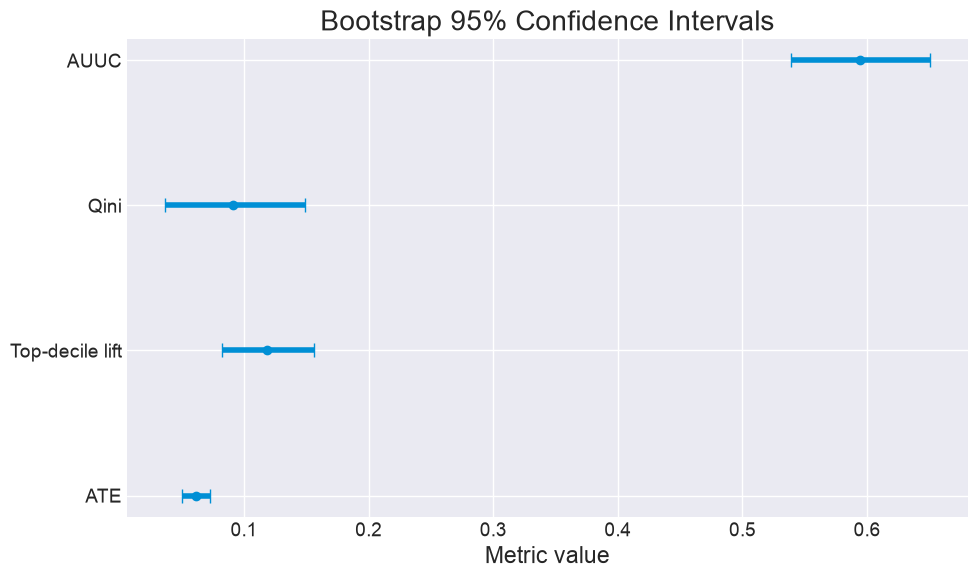

Saved: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/figures/bootstrap_confidence_intervals.png


In [13]:
plot_metrics = [
    "ate",
    "top_decile_lift",
    "qini",
    "auuc",
]

plot_summary = bootstrap_summary.loc[
    plot_metrics
].copy()

x_values = plot_summary["estimate"].to_numpy()

lower_errors = (
    plot_summary["estimate"]
    - plot_summary["ci_lower"]
).to_numpy()

upper_errors = (
    plot_summary["ci_upper"]
    - plot_summary["estimate"]
).to_numpy()

y_positions = np.arange(
    len(plot_summary)
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=x_values,
    y=y_positions,
    xerr=np.vstack([
        lower_errors,
        upper_errors,
    ]),
    fmt="o",
    capsize=5,
)

plt.yticks(
    y_positions,
    [
        "ATE",
        "Top-decile lift",
        "Qini",
        "AUUC",
    ],
)

plt.xlabel("Metric value")
plt.title(
    "Bootstrap 95% Confidence Intervals"
)

plt.tight_layout()

plt.savefig(
    BOOTSTRAP_CI_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved:", BOOTSTRAP_CI_PATH)

# Split Stability Check

The repeated-split check measures how much the main Logistic T-learner's targeting performance changes when the same full modeling sample is divided into different 75% training and 25% test sets.

Each split is stratified jointly by treatment and visit outcome. The original cross-validated logistic hyperparameters remain fixed across repetitions.

## 14. Reconstruct the full processed modeling sample

This section recombines the existing train and test files so multiple new random train/test splits can be drawn from the same processed dataset.

In [15]:
X_full = pd.concat(
    [X_train, X_test],
    ignore_index=True,
)

y_full = pd.concat(
    [y_train, y_test],
    ignore_index=True,
)

treatment_full = pd.concat(
    [treatment_train, treatment_test],
    ignore_index=True,
)

stratification_labels = (
    treatment_full.astype(str)
    + "_"
    + y_full.astype(str)
)

print("Full feature matrix:", X_full.shape)

display(
    pd.crosstab(
        treatment_full,
        y_full,
        margins=True,
    )
)

Full feature matrix: (64000, 18)


visit,0,1,All
treatment_binary,,,
0,19044,2262,21306
1,35562,7132,42694
All,54606,9394,64000


## 15. Re-fit and evaluate the Logistic T-learner across multiple splits

For each random split, this section re-fits the two logistic outcome models and records the test-set ATE, top-decile lift, Qini, and AUUC.

In [16]:
stability_rows = []

all_indices = np.arange(
    len(X_full)
)

for split_number in range(N_STABILITY_SPLITS):
    split_seed = (
        RANDOM_STATE
        + 300
        + split_number
    )

    train_index, test_index = train_test_split(
        all_indices,
        test_size=TEST_SIZE,
        random_state=split_seed,
        stratify=stratification_labels,
    )

    X_split_train = X_full.iloc[
        train_index
    ].reset_index(drop=True)

    y_split_train = y_full.iloc[
        train_index
    ].reset_index(drop=True)

    treatment_split_train = (
        treatment_full
        .iloc[train_index]
        .reset_index(drop=True)
    )

    X_split_test = X_full.iloc[
        test_index
    ].reset_index(drop=True)

    y_split_test = y_full.iloc[
        test_index
    ].reset_index(drop=True)

    treatment_split_test = (
        treatment_full
        .iloc[test_index]
        .reset_index(drop=True)
    )

    split_treated_model, split_control_model = (
        fit_logistic_t_learner(
            X=X_split_train,
            y=y_split_train,
            treatment=treatment_split_train,
        )
    )

    split_uplift = predict_t_learner_uplift(
        treated_model=split_treated_model,
        control_model=split_control_model,
        X=X_split_test,
    )

    split_metrics = evaluate_uplift(
        y=y_split_test,
        treatment=treatment_split_test,
        predicted_uplift=split_uplift,
        model_name=BEST_MODEL_NAME,
    )

    split_metrics["split_number"] = (
        split_number + 1
    )

    split_metrics["split_seed"] = (
        split_seed
    )

    split_metrics["top_decile_above_ate"] = (
        split_metrics["top_decile_lift"]
        > split_metrics["ate"]
    )

    stability_rows.append(split_metrics)

stability_results = pd.DataFrame(
    stability_rows
)

display(stability_results)

,ate,top_decile_lift,qini,auuc,split_number,split_seed,top_decile_above_ate
0,0.0610,0.0891,0.0478,0.5486,1,342,True
1,0.0610,0.0936,0.0816,0.5851,2,343,True
2,0.0610,0.0768,0.0199,0.5209,3,344,True
3,0.0608,0.0875,0.0772,0.5784,4,345,True
4,0.0608,0.0978,0.0784,0.5770,5,346,True
5,0.0610,0.0681,0.0306,0.5303,6,347,True
6,0.0610,0.1082,0.0967,0.5936,7,348,True
7,0.0610,0.0856,0.1076,0.6071,8,349,True
8,0.0610,0.1101,0.0929,0.5929,9,350,True
9,0.0608,0.1001,0.0749,0.5767,10,351,True


## 16. Summarize repeated-split stability

This section reports the requested mean and standard deviation of Qini, AUUC, and top-decile lift across the repeated train/test splits.

In [17]:
stability_summary = (
    stability_results[
        [
            "qini",
            "auuc",
            "top_decile_lift",
        ]
    ]
    .agg(["mean", "std"])
    .T
)

stability_summary["minimum"] = (
    stability_results[
        stability_summary.index
    ]
    .min()
)

stability_summary["maximum"] = (
    stability_results[
        stability_summary.index
    ]
    .max()
)

display(stability_summary)

print(
    "Share of splits with positive Qini:",
    (stability_results["qini"] > 0).mean(),
)

print(
    "Share of splits where top-decile lift > ATE:",
    stability_results[
        "top_decile_above_ate"
    ].mean(),
)

,mean,std,minimum,maximum
qini,0.0708,0.0288,0.0199,0.1076
auuc,0.5711,0.0284,0.5209,0.6071
top_decile_lift,0.0917,0.0132,0.0681,0.1101


Share of splits with positive Qini: 1.0
Share of splits where top-decile lift > ATE: 1.0


# Save Final Robustness Outputs

The final summary combines the original benchmark, placebo results, bootstrap uncertainty, and repeated-split stability into one tidy CSV. The required figures were saved in the earlier plotting sections.

## 17. Build and save `outputs/robustness_summary.csv`

Each row represents one metric from one robustness check. Bootstrap rows include confidence intervals, repeated-split rows include standard deviations, and original/placebo rows include their estimated random-targeting reference and distance from random.

In [18]:
summary_rows = []

baseline_reference_map = {
    "ate": baseline_metrics["ate"],
    "top_decile_lift":
        baseline_random_reference[
            "top_decile_lift"
        ],
    "qini":
        baseline_random_reference["qini"],
    "auuc":
        baseline_random_reference["auuc"],
}

placebo_reference_map = {
    "ate": placebo_metrics["ate"],
    "top_decile_lift":
        placebo_random_reference[
            "top_decile_lift"
        ],
    "qini":
        placebo_random_reference["qini"],
    "auuc":
        placebo_random_reference["auuc"],
}

for metric in [
    "ate",
    "top_decile_lift",
    "qini",
    "auuc",
]:
    summary_rows.append({
        "check": "original_model",
        "metric": metric,
        "estimate": baseline_metrics[metric],
        "std": np.nan,
        "ci_lower": np.nan,
        "ci_upper": np.nan,
        "random_reference":
            baseline_reference_map[metric],
        "distance_from_random": abs(
            baseline_metrics[metric]
            - baseline_reference_map[metric]
        ),
        "n_repetitions": 1,
    })

    summary_rows.append({
        "check": "placebo_treatment",
        "metric": metric,
        "estimate": placebo_metrics[metric],
        "std": np.nan,
        "ci_lower": np.nan,
        "ci_upper": np.nan,
        "random_reference":
            placebo_reference_map[metric],
        "distance_from_random": abs(
            placebo_metrics[metric]
            - placebo_reference_map[metric]
        ),
        "n_repetitions": 1,
    })

for metric in bootstrap_summary.index:
    summary_rows.append({
        "check": "bootstrap",
        "metric": metric,
        "estimate":
            bootstrap_summary.loc[
                metric,
                "estimate",
            ],
        "std":
            bootstrap_summary.loc[
                metric,
                "std",
            ],
        "ci_lower":
            bootstrap_summary.loc[
                metric,
                "ci_lower",
            ],
        "ci_upper":
            bootstrap_summary.loc[
                metric,
                "ci_upper",
            ],
        "random_reference": np.nan,
        "distance_from_random": np.nan,
        "n_repetitions":
            len(bootstrap_results),
    })

for metric in stability_summary.index:
    summary_rows.append({
        "check": "split_stability",
        "metric": metric,
        "estimate":
            stability_summary.loc[
                metric,
                "mean",
            ],
        "std":
            stability_summary.loc[
                metric,
                "std",
            ],
        "ci_lower": np.nan,
        "ci_upper": np.nan,
        "random_reference": np.nan,
        "distance_from_random": np.nan,
        "n_repetitions":
            len(stability_results),
    })

robustness_summary = pd.DataFrame(
    summary_rows
)

robustness_summary.to_csv(
    ROBUSTNESS_SUMMARY_PATH,
    index=False,
)

display(robustness_summary)

print("Saved:", ROBUSTNESS_SUMMARY_PATH)
print("Saved:", PLACEBO_QINI_PATH)
print("Saved:", BOOTSTRAP_CI_PATH)

,check,metric,estimate,std,ci_lower,ci_upper,random_reference,distance_from_random,n_repetitions
0,original_model,ate,0.0611,NaN,NaN,NaN,0.0611,0.0000,1
1,placebo_treatment,ate,0.0611,NaN,NaN,NaN,0.0611,0.0000,1
2,original_model,top_decile_lift,0.1184,NaN,NaN,NaN,0.0614,0.0570,1
3,placebo_treatment,top_decile_lift,0.1116,NaN,NaN,NaN,0.0614,0.0502,1
4,original_model,qini,0.0890,NaN,NaN,NaN,-0.0036,0.0926,1
5,placebo_treatment,qini,0.0858,NaN,NaN,NaN,-0.0036,0.0894,1
6,original_model,auuc,0.5920,NaN,NaN,NaN,0.4964,0.0956,1
7,placebo_treatment,auuc,0.5889,NaN,NaN,NaN,0.4964,0.0925,1
8,bootstrap,ate,0.0613,0.0054,0.0504,0.0724,NaN,NaN,300
9,bootstrap,top_decile_lift,0.1185,0.0192,0.0821,0.1561,NaN,NaN,300


Saved: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/robustness_summary.csv
Saved: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/figures/robustness_placebo_qini.png
Saved: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/figures/bootstrap_confidence_intervals.png


# Interpretation

The final interpretation uses transparent diagnostics rather than a single metric:

1. **Placebo:** Qini, AUUC, and top-decile lift should all move closer to their random-targeting references after treatment labels are shuffled.
2. **Bootstrap:** the confidence interval for `top_decile_minus_ate` indicates whether the best-ranked customers consistently outperform the average treatment effect.
3. **Split stability:** positive Qini and top-decile lift above the ATE should occur across most repeated train/test splits.

The code below labels the conclusion as **stable**, **uncertain**, or **sensitive** and prints the statistics behind that label.

In [19]:
placebo_all_closer = bool(
    placebo_comparison[
        "closer_to_random"
    ].all()
)

bootstrap_increment_ci_lower = float(
    bootstrap_summary.loc[
        "top_decile_minus_ate",
        "ci_lower",
    ]
)

bootstrap_increment_ci_upper = float(
    bootstrap_summary.loc[
        "top_decile_minus_ate",
        "ci_upper",
    ]
)

split_positive_qini_rate = float(
    (stability_results["qini"] > 0).mean()
)

split_top_above_ate_rate = float(
    stability_results[
        "top_decile_above_ate"
    ].mean()
)

if (
    placebo_all_closer
    and bootstrap_increment_ci_lower > 0
    and split_positive_qini_rate >= 0.80
    and split_top_above_ate_rate >= 0.80
):
    robustness_label = "STABLE"

    interpretation = (
        "The main uplift conclusion is stable. "
        "The placebo model moved closer to random targeting on all three ranking checks, "
        "the bootstrap interval for top-decile lift above the overall ATE remained positive, "
        "and the main targeting signal persisted across most repeated train/test splits."
    )

elif (
    placebo_all_closer
    and split_positive_qini_rate >= 0.50
):
    robustness_label = "UNCERTAIN"

    interpretation = (
        "The main uplift conclusion is directionally supported but uncertain. "
        "The placebo behavior is consistent with a real signal, but either the bootstrap "
        "uncertainty or the repeated-split variation shows that the strength of the "
        "top-ranked targeting advantage is not fully stable."
    )

else:
    robustness_label = "SENSITIVE"

    interpretation = (
        "The main uplift conclusion is sensitive to the robustness checks. "
        "At least one placebo comparison did not move closer to random targeting or the "
        "targeting signal did not persist reliably across alternative train/test splits."
    )

print("Robustness conclusion:", robustness_label)
print()
print(interpretation)

print()
print(
    "Bootstrap 95% CI for top-decile lift minus ATE:",
    (
        bootstrap_increment_ci_lower,
        bootstrap_increment_ci_upper,
    ),
)

print(
    "Share of repeated splits with positive Qini:",
    split_positive_qini_rate,
)

print(
    "Share of repeated splits with top-decile lift > ATE:",
    split_top_above_ate_rate,
)

Robustness conclusion: STABLE

The main uplift conclusion is stable. The placebo model moved closer to random targeting on all three ranking checks, the bootstrap interval for top-decile lift above the overall ATE remained positive, and the main targeting signal persisted across most repeated train/test splits.

Bootstrap 95% CI for top-decile lift minus ATE: (0.025010938208977804, 0.09174935916265615)
Share of repeated splits with positive Qini: 1.0
Share of repeated splits with top-decile lift > ATE: 1.0


## Final output files

After the notebook runs successfully, it creates:

- `outputs/robustness_summary.csv`
- `outputs/figures/robustness_placebo_qini.png`
- `outputs/figures/bootstrap_confidence_intervals.png`

The summary CSV is designed to be easy to merge into the later unified evaluation/reporting workflow.